# CSI 300 Exploratory Data Analysis

This focused EDA uses the processed artifacts generated by the cumulative project pipeline.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)


working from: hmm_course_project


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.eda import eda_summary

daily = pd.read_csv('data/processed/hs300_clean.csv', parse_dates=['date'])
features = pd.read_csv('data/processed/period_features.csv', parse_dates=['date', 'next_date'])
print('daily shape:', daily.shape, 'feature shape:', features.shape)
display(eda_summary(daily).round(4))


Matplotlib is building the font cache; this may take a moment.


daily shape: (5261, 9) feature shape: (262, 8)


,column,dtype,count,missing,unique,mean,std,min,max,skew
0,date,datetime64[us],5261,0,5261,NaN,NaN,NaN,NaN,NaN
1,open,float64,5261,0,5254,3.329427e+03,1.085005e+03,8.165460e+02,5.922071e+03,-0.3704
2,high,float64,5261,0,5257,3.359195e+03,1.092706e+03,8.238600e+02,5.930912e+03,-0.3732
3,low,float64,5261,0,5259,3.299784e+03,1.075024e+03,8.077840e+02,5.815609e+03,-0.3771
4,close,float64,5261,0,5257,3.332107e+03,1.084630e+03,8.180330e+02,5.877202e+03,-0.3735
5,volume,float64,5261,0,5261,1.117292e+10,8.368353e+09,5.014525e+08,6.864391e+10,1.9467
6,daily_return,float64,5260,1,5260,4.000000e-04,1.580000e-02,-9.240000e-02,9.340000e-02,-0.3316
7,log_return,float64,5260,1,5260,3.000000e-04,1.580000e-02,-9.690000e-02,8.930000e-02,-0.4819
8,return_outlier,bool,5261,0,2,1.350000e-02,1.154000e-01,0.000000e+00,1.000000e+00,8.4352


## Distributions and outliers

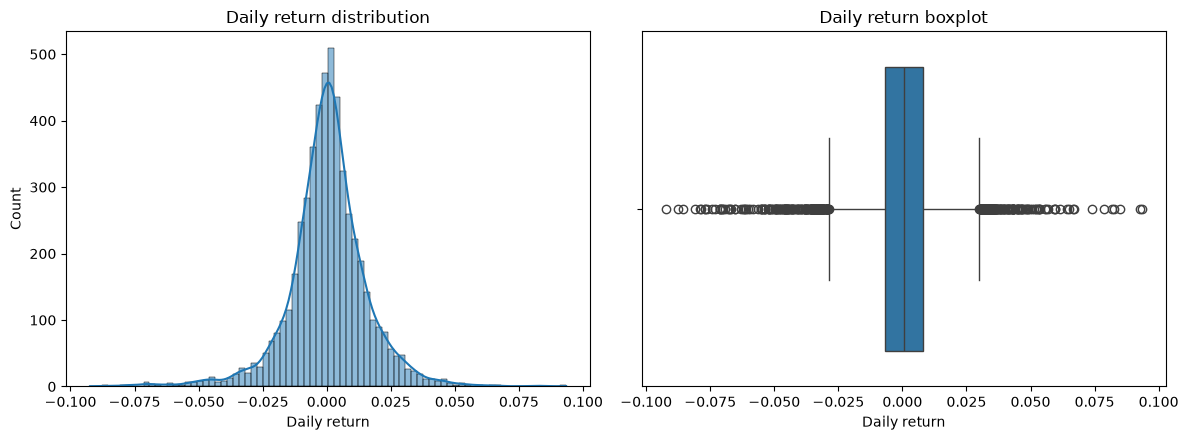

3-IQR flagged observations: 71


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(daily['daily_return'].dropna(), bins=80, kde=True, ax=axes[0])
axes[0].set(title='Daily return distribution', xlabel='Daily return')
sns.boxplot(x=daily['daily_return'].dropna(), ax=axes[1])
axes[1].set(title='Daily return boxplot', xlabel='Daily return')
plt.tight_layout()
plt.show()
print('3-IQR flagged observations:', int(daily['return_outlier'].sum()))


## Feature relationships

,count,mean,std,min,25%,50%,75%,max
period_return,262.0,0.0085,0.0732,-0.1987,-0.0323,0.0051,0.0444,0.2996
return_sharpe,262.0,0.2036,1.0873,-2.3185,-0.5540,0.1219,0.8397,3.0108
volume_ratio,262.0,0.0062,0.1159,-0.2251,-0.0762,-0.0056,0.0772,0.5338
half_return,262.0,0.0049,0.0505,-0.1641,-0.0235,0.0048,0.0290,0.2143
future_return,262.0,0.0086,0.0731,-0.1987,-0.0323,0.0056,0.0444,0.2996


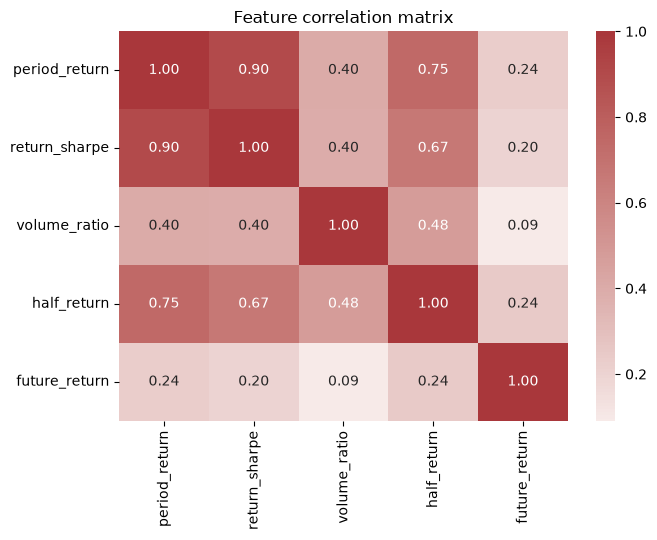

In [4]:
columns = ['period_return', 'return_sharpe', 'volume_ratio', 'half_return', 'future_return']
display(features[columns].describe().T.round(4))
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(features[columns].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()


## EDA Findings

1. Daily returns are heavy-tailed, so valid extremes are flagged and retained.
2. The 10-day and 20-day return features are correlated by construction; the HMM is descriptive rather than causal.
3. Volume changes add a different dimension, but provider definitions can drift and require monitoring.
4. Chronological modeling is required because random splitting would expose future regimes to training.